In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/consumption/1pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.177485
2017-11-25 01:10:00,-1.293020,-1.195925
2017-11-25 01:20:00,-1.333732,-1.326232
2017-11-25 01:30:00,-1.353240,-1.338253
2017-11-25 01:40:00,-1.345607,-1.355172


In [4]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/consumption/1pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.208620
2017-11-25 01:10:00,-1.293020,-1.218250
2017-11-25 01:20:00,-1.333732,-1.345911
2017-11-25 01:30:00,-1.353240,-1.381871
2017-11-25 01:40:00,-1.345607,-1.385889


In [5]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/consumption/1pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.192128
2017-11-25 01:10:00,-1.293020,-1.209923
2017-11-25 01:20:00,-1.333732,-1.337083
2017-11-25 01:30:00,-1.353240,-1.345165
2017-11-25 01:40:00,-1.345607,-1.361422


In [6]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.153065
2017-11-25 01:10:00,-1.293020,-1.188033
2017-11-25 01:20:00,-1.333732,-1.306982
2017-11-25 01:30:00,-1.353240,-1.322111
2017-11-25 01:40:00,-1.345607,-1.330723


In [7]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.164902
2017-11-25 01:10:00,-1.293020,-1.207155
2017-11-25 01:20:00,-1.333732,-1.322870
2017-11-25 01:30:00,-1.353240,-1.358101
2017-11-25 01:40:00,-1.345607,-1.372037


In [8]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 5347 - 5190
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.137862
2017-11-25 01:10:00,-1.293020,-1.182956
2017-11-25 01:20:00,-1.333732,-1.364835
2017-11-25 01:30:00,-1.353240,-1.340733
2017-11-25 01:40:00,-1.345607,-1.368772


## MLP ##

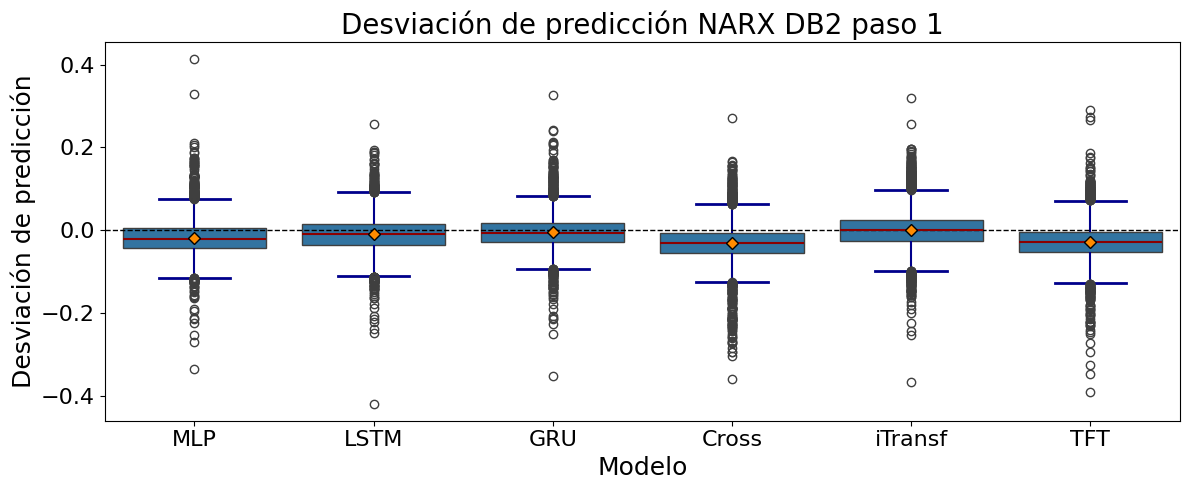

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARX DB2 paso 1', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda

# Ajustar la presentación
plt.tight_layout()
plt.show()


# Graficos Q-Q

In [10]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:00:00,-0.007819,0.023316,0.006825,-0.032238,-0.020401,-0.047442
2017-11-25 01:10:00,-0.097095,-0.074770,-0.083098,-0.104988,-0.085866,-0.110064
2017-11-25 01:20:00,-0.007500,0.012178,0.003351,-0.026750,-0.010862,0.031103
2017-11-25 01:30:00,-0.014987,0.028630,-0.008076,-0.031129,0.004861,-0.012507
2017-11-25 01:40:00,0.009566,0.040283,0.015815,-0.014883,0.026430,0.023165


In [11]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [12]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-12-05 22:30:00,-0.087939,-0.067051,-0.038040,-0.049182,-0.035157,-0.054240
2017-11-30 06:10:00,0.034689,-0.009594,0.011665,0.027622,0.016922,0.017851
2017-12-15 23:50:00,-0.069552,-0.031374,-0.036547,-0.066951,-0.030163,-0.083823
2017-12-24 08:50:00,0.004374,-0.037964,-0.029978,0.005768,-0.019599,0.003689
2017-12-22 19:50:00,0.012842,0.011859,0.056080,0.018472,0.065164,0.044505


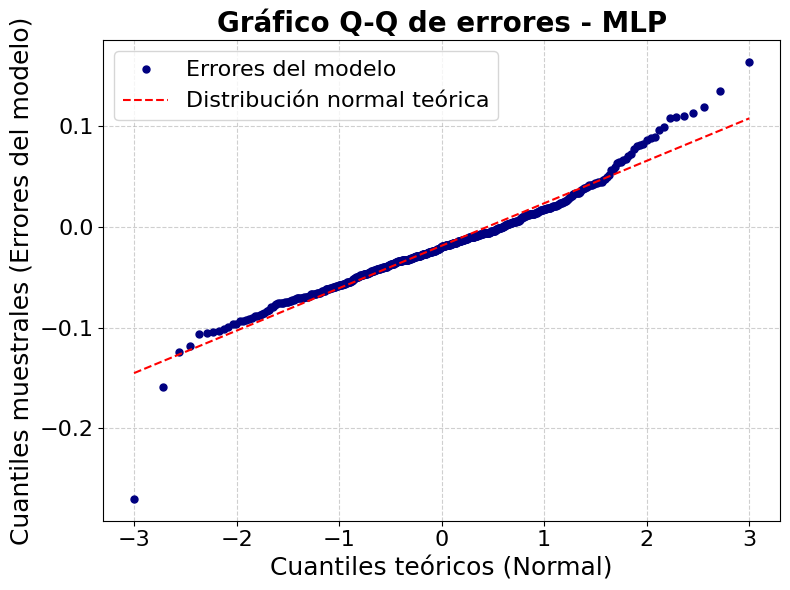

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


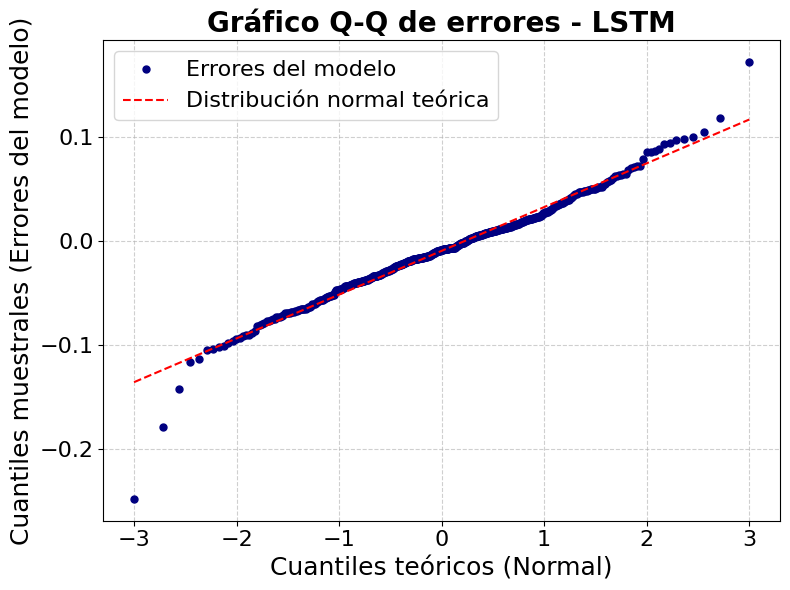

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


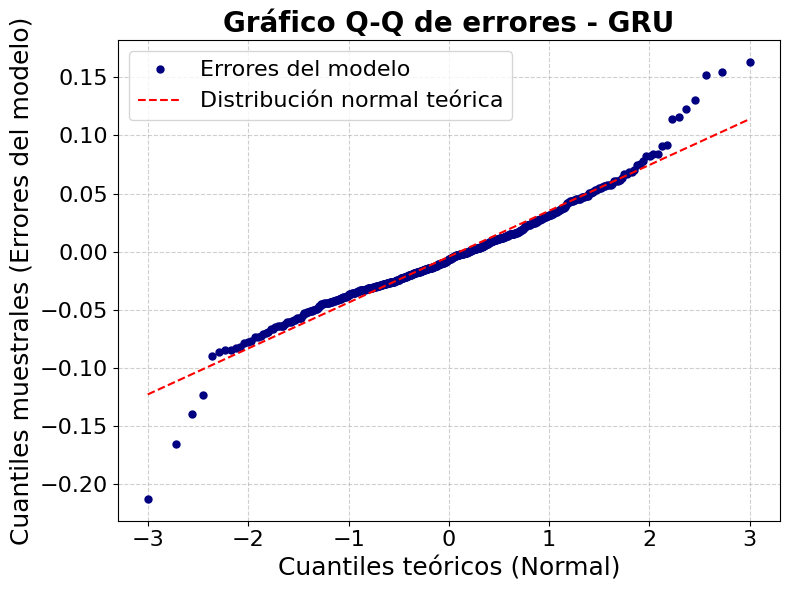

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


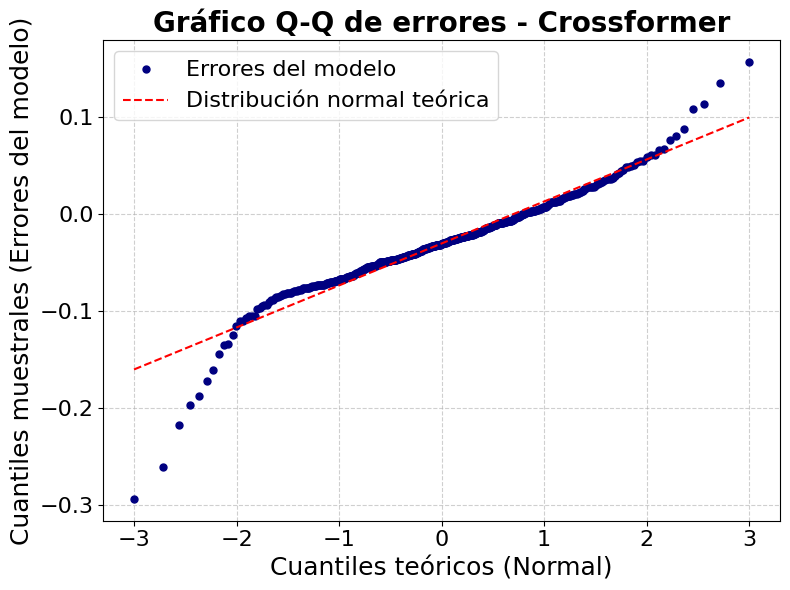

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


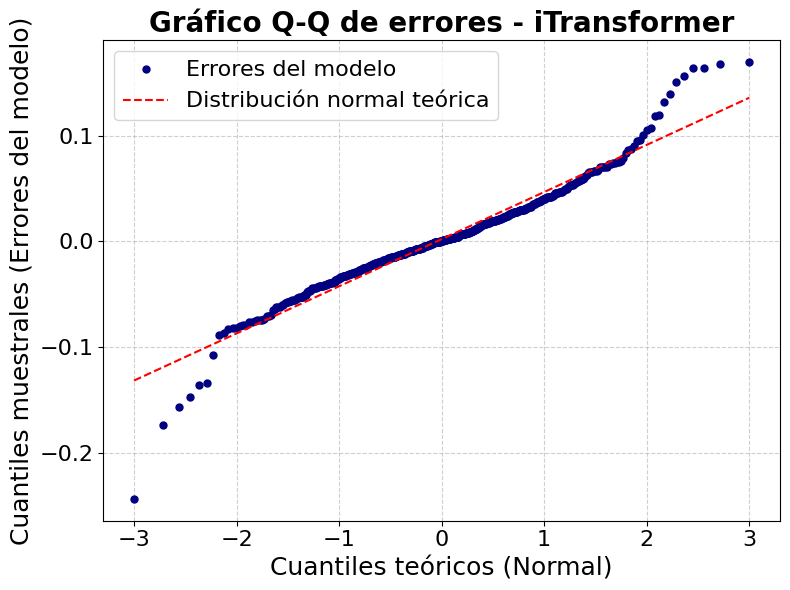

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


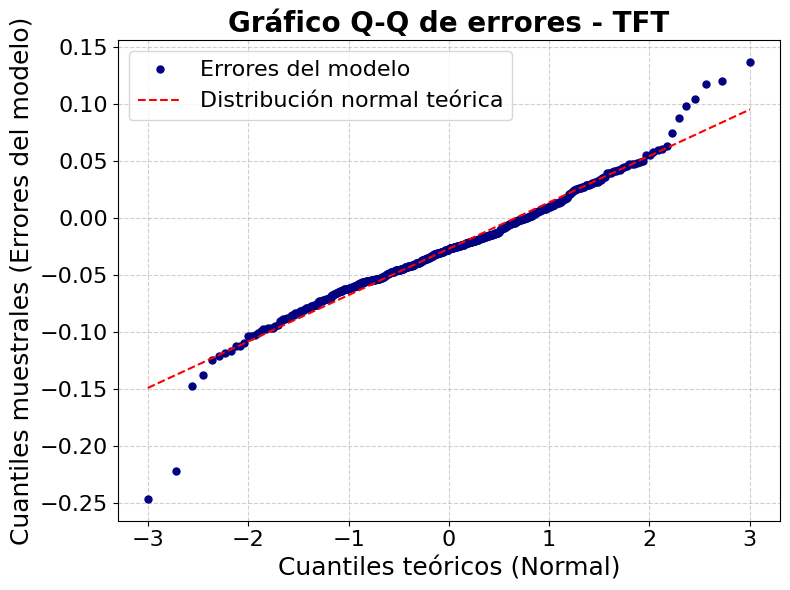

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

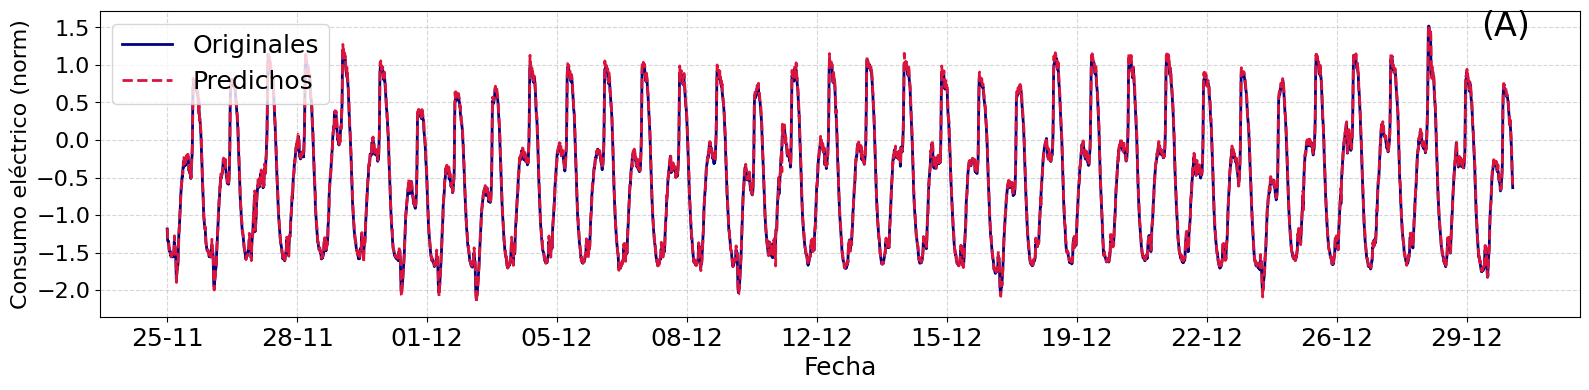

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.figure(figsize=(16, 4))

df = datosMLP
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()


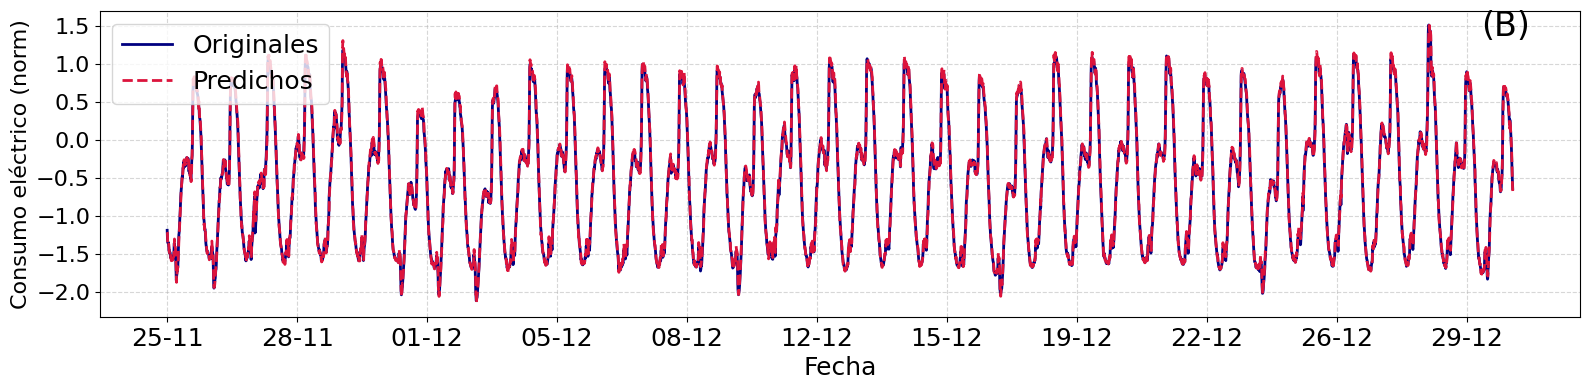

In [20]:

plt.figure(figsize=(16, 4))

df = datosLSTM
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

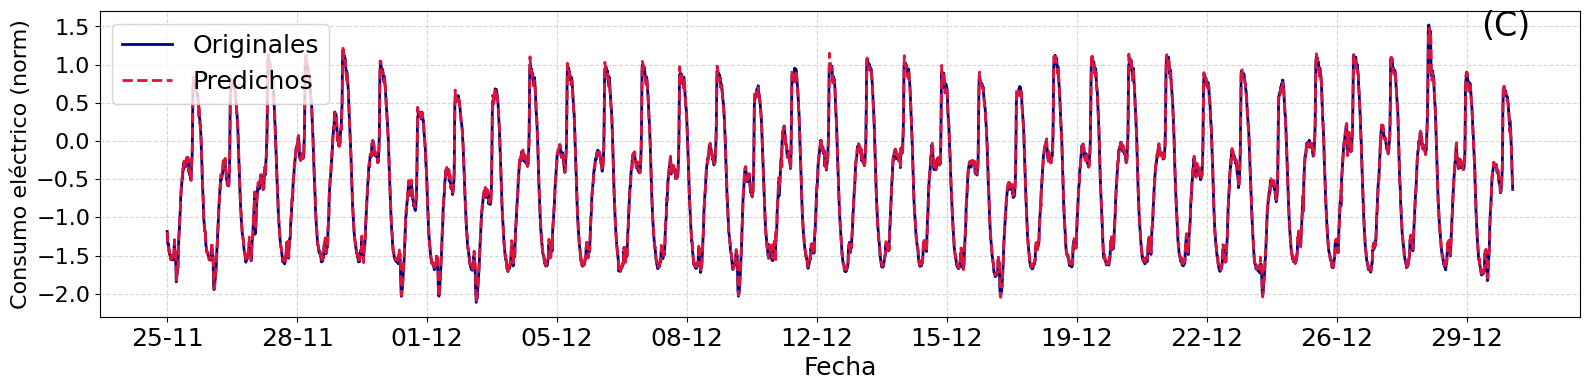

In [21]:

plt.figure(figsize=(16, 4))

df = datosGRU
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

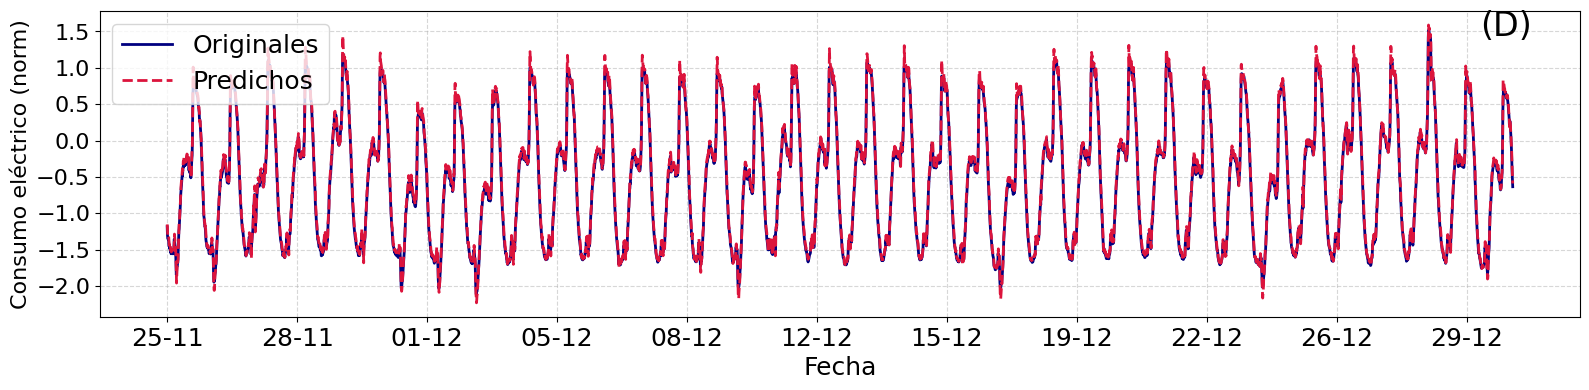

In [22]:

plt.figure(figsize=(16, 4))

df = datosCross
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

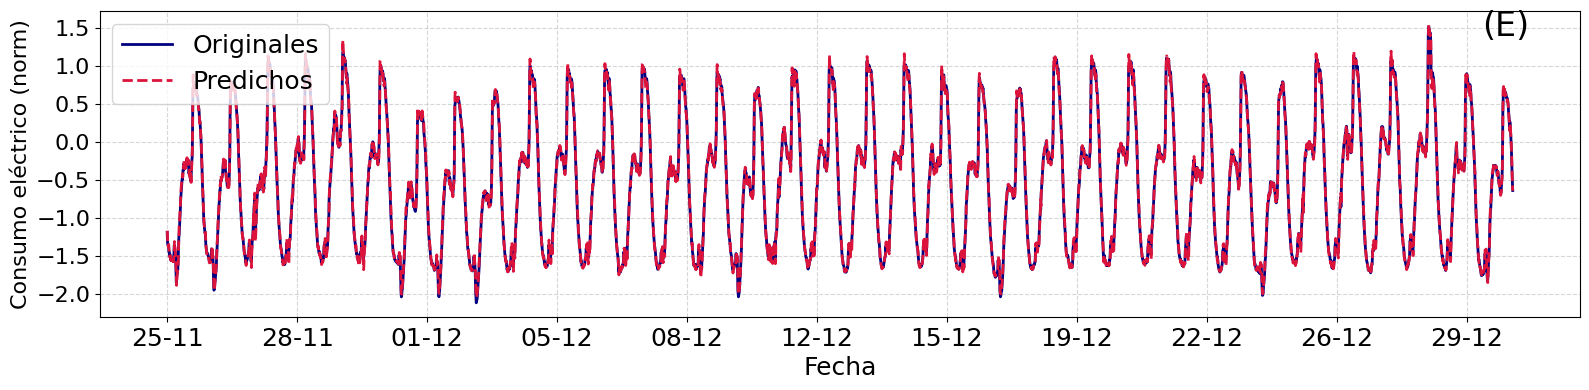

In [23]:

plt.figure(figsize=(16, 4))

df = datosI
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

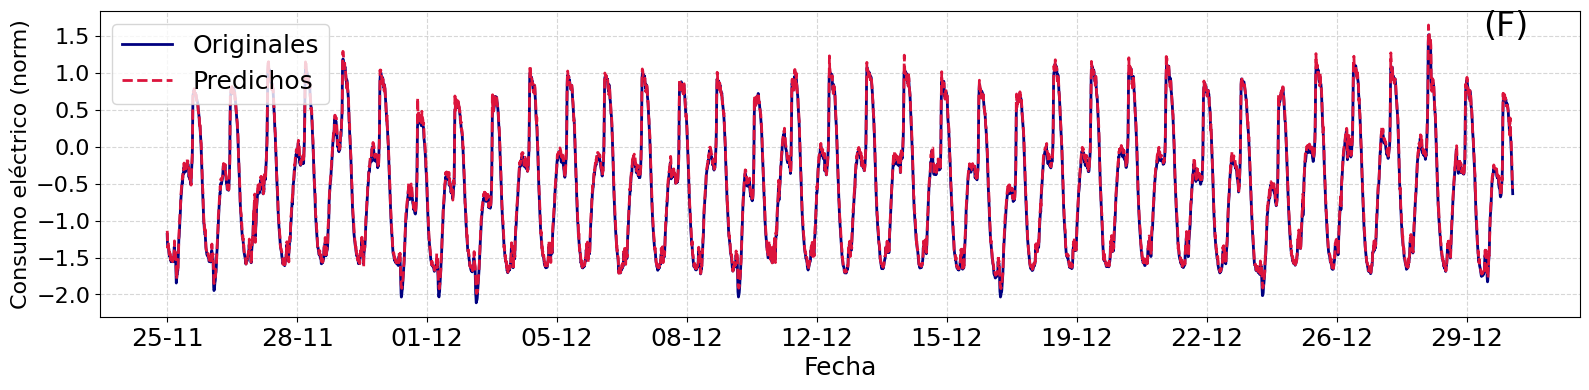

In [24]:

plt.figure(figsize=(16, 4))

df = datosTFT
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

# Métricas

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [26]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.002161515965466939
RMSE: 0.04649210648558462
MAE: 0.03573939871793805
SMAPE: 0.12576562211550613
IA: 0.9754576861312404


In [27]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0019440812248267547
RMSE: 0.044091736468716614
MAE: 0.03339076269821408
SMAPE: 0.11399625597824085
IA: 0.9770107336829954


In [28]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0016669441767493793
RMSE: 0.0408282276954239
MAE: 0.0298440494667219
SMAPE: 0.09914249898077565
IA: 0.97928430831356


In [29]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0030394119049075036
RMSE: 0.05513086163763
MAE: 0.04274199424162901
SMAPE: 0.13502294031104498
IA: 0.9706204802391036


In [30]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0020878333346526575
RMSE: 0.04569281491277001
MAE: 0.03324171288639301
SMAPE: 0.10988555703038075
IA: 0.9769714928485164


In [31]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0028402810517882213
RMSE: 0.05329428723407623
MAE: 0.041275104901137914
SMAPE: 0.14533521936213925
IA: 0.9714473265623226


# Pruebas de significación

In [32]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [33]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 3.164423603928942e-96
LSTM: 2.9458254051252046e-98
GRU: 2.8286392980918544e-99
Cross: 7.726192449066507e-101
iTransf: 7.980085759253185e-97
TFT: 2.1279221354703525e-101


In [34]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

2.7228912197015578e-167


In [35]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00000,0.00000,0.00000
1,MLP vs GRU,0.00000,0.00000,0.00000
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.00000,0.00000,0.00000
5,LSTM vs GRU,0.00509,0.07642,0.00509
6,LSTM vs Crossformer,0.00000,0.00000,0.00000
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00000,0.00000,0.00000
